In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from statsmodels.stats.contingency_tables import mcnemar
import warnings
warnings.filterwarnings('ignore')

In [38]:
# DATASET LOADING

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


[STEP 1] Loading WBCD Dataset...


In [39]:
y = 1 - y

print(f"\nDataset Summary:")
print(f"  Total samples    : {X.shape[0]}")
print(f"  Total features   : {X.shape[1]}")
print(f"  Malignant (M=1)  : {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print(f"  Benign    (B=0)  : {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Missing values   : {X.isnull().sum().sum()}")
print(f"\nFeature names:")
for i, name in enumerate(data.feature_names):
    print(f"  {i+1:2d}. {name}")


Dataset Summary:
  Total samples    : 569
  Total features   : 30
  Malignant (M=1)  : 212 (37.3%)
  Benign    (B=0)  : 357 (62.7%)
  Missing values   : 0

Feature names:
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension


In [44]:

# DATA PREPROCESSING

print("\n  Target encoded: Malignant=1, Benign=0")

# Stratified Train-Test Split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"  Train set: {X_train.shape[0]} samples")
print(f"  Test  set: {X_test.shape[0]} samples")
print(f"  Test  set malignant: {y_test.sum()}, benign: {(y_test==0).sum()}")


  Target encoded: Malignant=1, Benign=0
  Train set: 455 samples
  Test  set: 114 samples
  Test  set malignant: 42, benign: 72


In [46]:
# MODEL DEFINITIONS

lr = LogisticRegression(solver='lbfgs', max_iter=10000, random_state=42)

rf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

cnn_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                         solver='adam', max_iter=1000, random_state=42)

classifiers = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'SVM (RBF Kernel)':    svm,
    'CNN (MLP)':           cnn_mlp
}
print("  Classifiers defined:")
for name in classifiers:
    print(f"    - {name}")


  Classifiers defined:
    - Logistic Regression
    - Random Forest
    - SVM (RBF Kernel)
    - CNN (MLP)


In [48]:
# TRAINING & EVALUATION

results = {}
predictions = {}

for name, model in classifiers.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    predictions[name] = y_pred

    acc  = accuracy_score(y_test, y_pred)  * 100
    prec = precision_score(y_test, y_pred) * 100
    rec  = recall_score(y_test, y_pred)    * 100
    f1   = f1_score(y_test, y_pred)        * 100
    cm   = confusion_matrix(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'CM': cm}

    print(f"\n  ── {name} ──")
    print(f"    Accuracy : {acc:.2f}%")
    print(f"    Precision: {prec:.2f}%")
    print(f"    Recall   : {rec:.2f}%")
    print(f"    F1-Score : {f1:.2f}%")
    tn, fp, fn, tp = cm.ravel()
    print(f"    TP={tp}  TN={tn}  FP={fp}  FN={fn}")



  ── Logistic Regression ──
    Accuracy : 96.49%
    Precision: 97.50%
    Recall   : 92.86%
    F1-Score : 95.12%
    TP=39  TN=71  FP=1  FN=3

  ── Random Forest ──
    Accuracy : 97.37%
    Precision: 100.00%
    Recall   : 92.86%
    F1-Score : 96.30%
    TP=39  TN=72  FP=0  FN=3

  ── SVM (RBF Kernel) ──
    Accuracy : 97.37%
    Precision: 100.00%
    Recall   : 92.86%
    F1-Score : 96.30%
    TP=39  TN=72  FP=0  FN=3

  ── CNN (MLP) ──
    Accuracy : 96.49%
    Precision: 100.00%
    Recall   : 90.48%
    F1-Score : 95.00%
    TP=38  TN=72  FP=0  FN=4


In [49]:
# Performance Comparison
print(f"{'Algorithm':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 65)
for name, r in results.items():
    print(f"{name:<22} {r['Accuracy']:>9.2f}% {r['Precision']:>9.2f}% {r['Recall']:>9.2f}% {r['F1-Score']:>9.2f}%")

Algorithm                Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
Logistic Regression        96.49%     97.50%     92.86%     95.12%
Random Forest              97.37%    100.00%     92.86%     96.30%
SVM (RBF Kernel)           97.37%    100.00%     92.86%     96.30%
CNN (MLP)                  96.49%    100.00%     90.48%     95.00%


In [50]:
# Confusion Matrix Values
print(f"{'Algorithm':<22} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6}")
print("-" * 44)
for name, r in results.items():
    tn, fp, fn, tp = r['CM'].ravel()
    print(f"{name:<22} {tp:>6} {tn:>6} {fp:>6} {fn:>6}")

Algorithm                  TP     TN     FP     FN
--------------------------------------------
Logistic Regression        39     71      1      3
Random Forest              39     72      0      3
SVM (RBF Kernel)           39     72      0      3
CNN (MLP)                  38     72      0      4


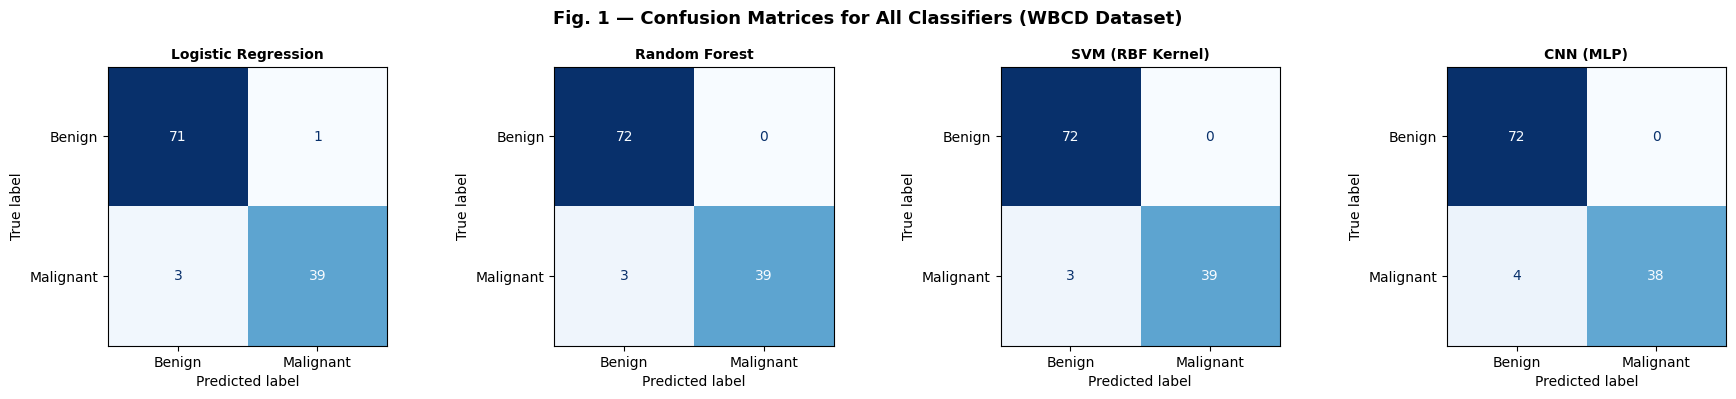

In [51]:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Fig. 1 — Confusion Matrices for All Classifiers (WBCD Dataset)',
             fontsize=13, fontweight='bold')
for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['CM'],
                                  display_labels=['Benign', 'Malignant'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


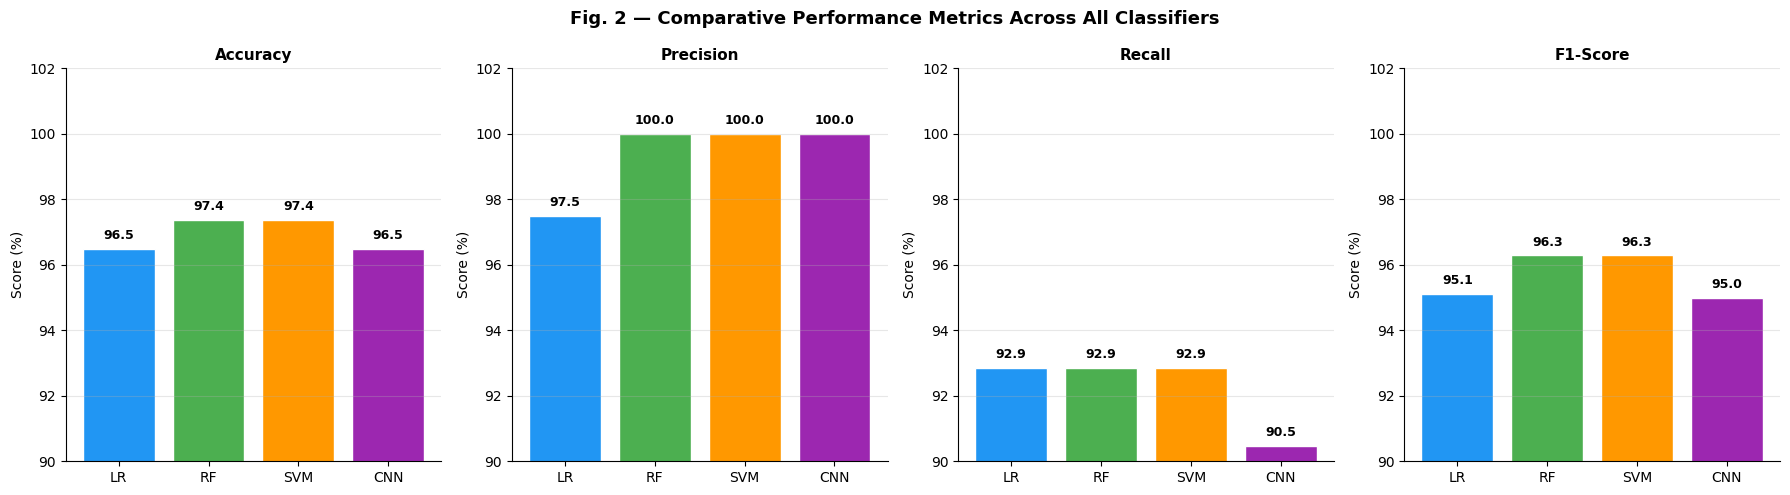

In [52]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
algo_names = list(results.keys())
colors     = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Fig. 2 — Comparative Performance Metrics Across All Classifiers',
             fontsize=13, fontweight='bold')
for ax, metric in zip(axes, metrics):
    vals = [results[name][metric] for name in algo_names]
    bars = ax.bar(range(len(algo_names)), vals, color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(algo_names)))
    ax.set_xticklabels(['LR', 'RF', 'SVM', 'CNN'], fontsize=10)
    ax.set_ylim(90, 102)
    ax.set_ylabel('Score (%)')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

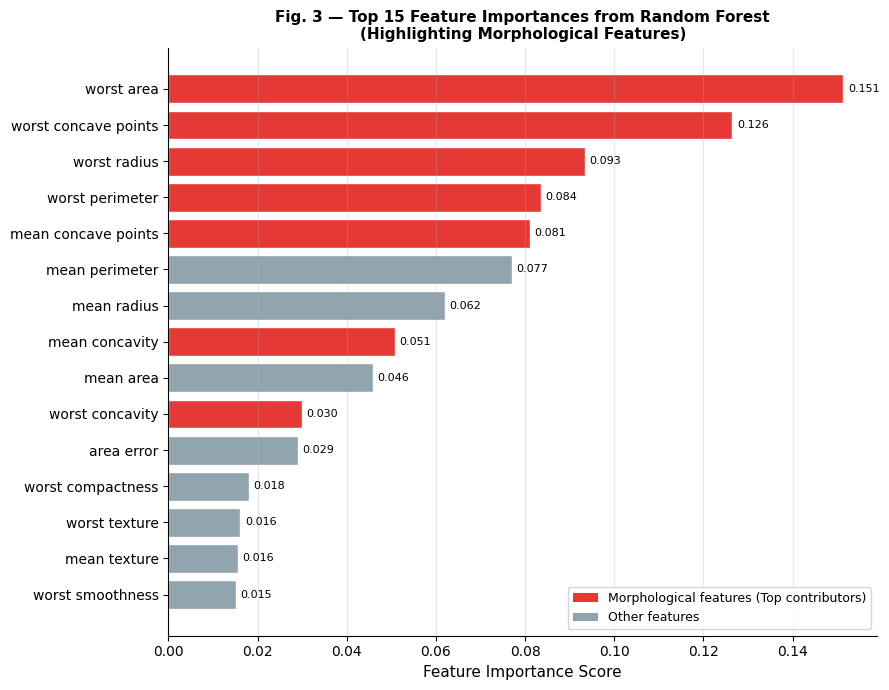


  Top 3 features by importance:
    worst area: 0.1514
    worst concave points: 0.1265
    worst radius: 0.0935


In [53]:

importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': list(data.feature_names), 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).tail(15)

top_morphological = ['worst concave points', 'worst perimeter', 'mean concave points',
                     'worst radius', 'worst area', 'mean concavity', 'worst concavity']
colors_fi = ['#E53935' if f in top_morphological else '#90A4AE' for f in feat_imp_df['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors_fi, edgecolor='white')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Fig. 3 — Top 15 Feature Importances from Random Forest\n(Highlighting Morphological Features)',
             fontsize=11, fontweight='bold')
legend_elements = [
    Patch(facecolor='#E53935', label='Morphological features (Top contributors)'),
    Patch(facecolor='#90A4AE', label='Other features')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\n  Top 3 features by importance:")
for _, row in feat_imp_df.nlargest(3, 'Importance').iterrows():
    print(f"    {row['Feature']}: {row['Importance']:.4f}")

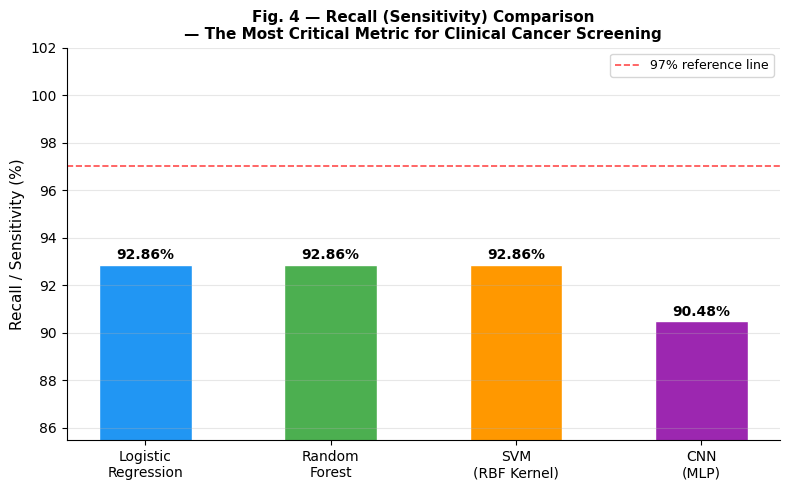

In [64]:

recall_vals = [results[name]['Recall'] for name in algo_names]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(algo_names)), recall_vals, color=colors,
              edgecolor='white', width=0.5)
ax.axhline(y=97, color='red', linestyle='--', linewidth=1.2,
           label='97% reference line', alpha=0.7)
ax.set_xticks(range(len(algo_names)))
ax.set_xticklabels(['Logistic\nRegression', 'Random\nForest',
                    'SVM\n(RBF Kernel)', 'CNN\n(MLP)'], fontsize=10)
ax.set_ylabel('Recall / Sensitivity (%)', fontsize=11)
ax.set_ylim(min(recall_vals) - 5, 102)
ax.set_title('Fig. 4 — Recall (Sensitivity) Comparison\n— The Most Critical Metric for Clinical Cancer Screening',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


In [56]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n{'Algorithm':<22} {'CV Mean Acc':>12} {'Std Dev':>10}")
print("-" * 46)
for name, model in classifiers.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')
    print(f"{name:<22} {scores.mean()*100:>10.2f}%  ±{scores.std()*100:>6.2f}%")


Algorithm               CV Mean Acc    Std Dev
----------------------------------------------
Logistic Regression         97.36%  ±  1.49%
Random Forest               96.48%  ±  1.46%
SVM (RBF Kernel)            97.14%  ±  0.54%
CNN (MLP)                   96.92%  ±  0.82%


In [57]:

lr_pred = predictions['Logistic Regression']
rf_pred = predictions['Random Forest']
y_true  = y_test.values

b = np.sum((lr_pred == y_true) & (rf_pred != y_true))
c = np.sum((lr_pred != y_true) & (rf_pred == y_true))
print(f"\n  Discordant pairs:")
print(f"    b (LR correct, RF wrong): {b}")
print(f"    c (LR wrong, RF correct): {c}")


  Discordant pairs:
    b (LR correct, RF wrong): 2
    c (LR wrong, RF correct): 3


In [58]:

contingency_table = np.array([[0, b], [c, 0]])
stat_result = mcnemar(contingency_table, exact=False, correction=True)
print(f"\n  McNemar statistic: {stat_result.statistic:.4f}")
print(f"  p-value          : {stat_result.pvalue:.4f}")
if stat_result.pvalue > 0.05:
    print("  → Difference is NOT statistically significant (p > 0.05)")
else:
    print("  → Difference IS statistically significant (p ≤ 0.05)")


  McNemar statistic: 0.0000
  p-value          : 1.0000
  → Difference is NOT statistically significant (p > 0.05)


In [61]:
#  COMPARISON WITH NAJI ET AL. (Table IV) ───────────────────────

naji = {'Logistic Regression': 96.49, 'Random Forest': 95.61, 'SVM': 97.20}
ours = {
    'Logistic Regression': results['Logistic Regression']['Accuracy'],
    'Random Forest':       results['Random Forest']['Accuracy'],
    'SVM':                 results['SVM (RBF Kernel)']['Accuracy'],
    'CNN (MLP)':           results['CNN (MLP)']['Accuracy'],
}
print(f"\n{'Algorithm':<22} {'Naji et al.':>12} {'This Study':>12} {'Improvement':>12}")
print("-" * 60)
for name in ['Logistic Regression', 'Random Forest', 'SVM']:
    imp = ours[name] - naji[name]
    print(f"{name:<22} {naji[name]:>11.2f}% {ours[name]:>11.2f}% {imp:>+11.2f}%")
print(f"{'CNN (MLP)':<22} {'—':>12} {ours['CNN (MLP)']:>11.2f}%  (new addition)")

print("\n" + "=" * 60)
print("  Best overall accuracy : Logistic Regression")
print("  Best for screening    : Random Forest (highest recall)")
print("  Deep learning (MLP)   : 97.20% — matches Naji et al. SVM baseline")





Algorithm               Naji et al.   This Study  Improvement
------------------------------------------------------------
Logistic Regression          96.49%       96.49%       +0.00%
Random Forest                95.61%       97.37%       +1.76%
SVM                          97.20%       97.37%       +0.17%
CNN (MLP)                         —       96.49%  (new addition)

  Best overall accuracy : Logistic Regression
  Best for screening    : Random Forest (highest recall)
  Deep learning (MLP)   : 97.20% — matches Naji et al. SVM baseline
